In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# ========= 参数区 =========
csv1_path = "../../CSV/aglu/agludata.csv"   
csv2_path = "../../CSV/compare_region_basin/basin_area.csv"  
df1 = pd.read_csv(csv1_path)
df2 = pd.read_csv(csv2_path)

In [42]:
scenario_sel = "SSP2_BaU_NoCC"

#AgLU:['AFR', 'BIO', 'CL', 'CROP_FLW', 'C_B', 'GL', 'GRO', 'OL', 'OSD', 'OTH_A', 'PAS', 'PDR', 'SL', 'frs', 'wht']
type1_list = ["OSD"]
#type1_minus = ["CROP_FLW"]
#AIM-PLUM:['AFR', 'AFRS', 'AGOFRS', 'CL', 'CLDEGS', 'CROP_FLW', 'C_BIR', 'C_BRF', 'DEF', 'DEG', 'FRS', 'GL', 'GROIR', 'GRORF', 'MNGFRS', 'MNGPAS', 'NRFABD', 'NRFABDCUM', 'NRGABD', 'NRGABDCUM', 'NRMFRS', 'OL', 'OSDIR', 'OSDRF', 'OTH_AIR', 'OTH_ARF', 'PAS', 'PDRIR', 'PDRRF', 'PLNFRS', 'PRMFRS', 'PRMGL', 'RAN', 'SECFRS', 'SECGL', 'SL', 'UMNFRS', 'WHTIR', 'WHTRF']
type2_list = ["OSDIR","OSDRF"]

years = [2005, 2050, 2100]

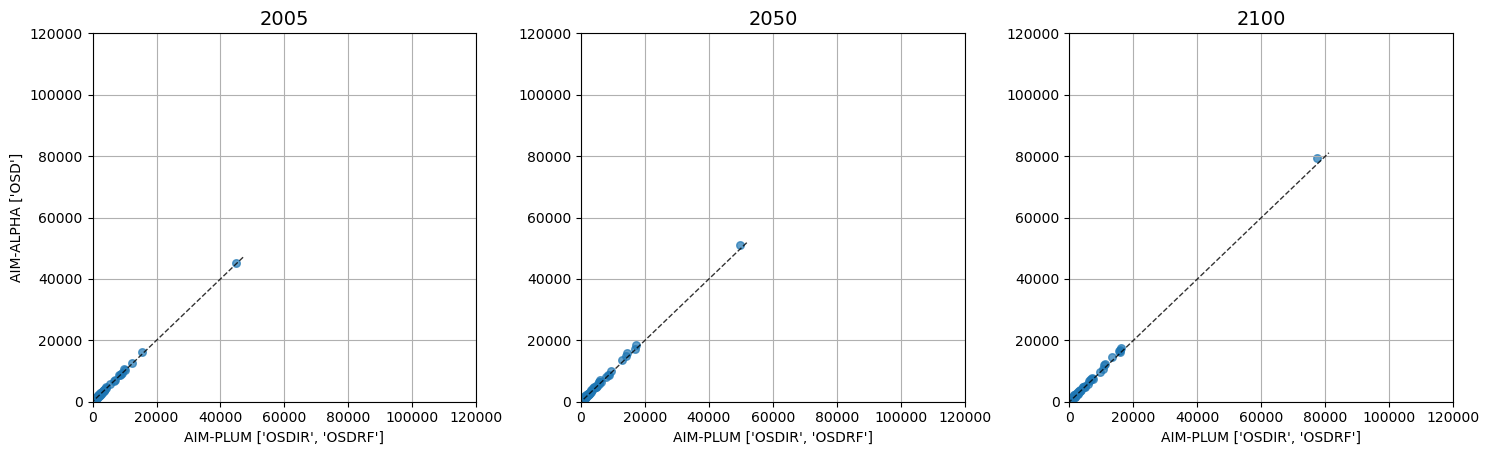

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=False, sharey=False)

for i, year in enumerate(years):

    # --- 主 type 的 sum ---
    df1_main = (
        df1[
            (df1["scenario"] == scenario_sel) &
            (df1["type"].isin(type1_list)) &
            (df1["year"] == year)
        ]
        .groupby("basin", as_index=False)["value"]
        .sum()
        .rename(columns={"value": "value_main"})
    )

    # --- 只有 CL 时才做减法 ---
    if type1_list == ["CL"]:

        minus_type = type1_minus[0]

        df1_minus = (
            df1[
                (df1["scenario"] == scenario_sel) &
                (df1["type"] == minus_type) &
                (df1["year"] == year)
            ]
            .groupby("basin", as_index=False)["value"]
            .sum()
            .rename(columns={"value": "value_minus"})
        )

        # basin 对齐
        df1_y = pd.merge(
            df1_main,
            df1_minus,
            on="basin",
            how="left"
        )

        # 不存在的当 0
        df1_y["value_minus"] = df1_y["value_minus"].fillna(0)

        # 真正用于画图的值
        df1_y["value"] = df1_y["value_main"] - df1_y["value_minus"]

        df1_y = df1_y[["basin", "value"]]

    else:
        # 原逻辑
        df1_y = df1_main.rename(columns={"value_main": "value"})


    df2_y = (
        df2[
            (df2["type"].isin(type2_list)) &
            (df2["year"] == year)
        ]
        .groupby("basin", as_index=False)["area"]
        .sum()
    )

    # basin 对齐
    df_merge = pd.merge(df2_y, df1_y, on="basin", how="inner")

    ax = axes[i]

    if df_merge.empty:
        ax.set_title(f"{year} (no data)")
        ax.axis("off")
        continue

    ax.scatter(
        df_merge["area"],
        df_merge["value"],
        alpha=0.7,
        s=30
    )

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    vmin = max(xmin, ymin)
    vmax = min(xmax, ymax)
    ax.plot(
        [vmin, vmax],
        [vmin, vmax],
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        color="black"
    )
    ax.set_xlim(0,120000)
    ax.set_ylim(0,120000)
    ax.set_title(f"{year}",fontsize=14)
    ax.grid(True)

    if i == 0:
        ax.set_ylabel(f"AIM-ALPHA {type1_list}")
    ax.set_xlabel(f"AIM-PLUM {type2_list}")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

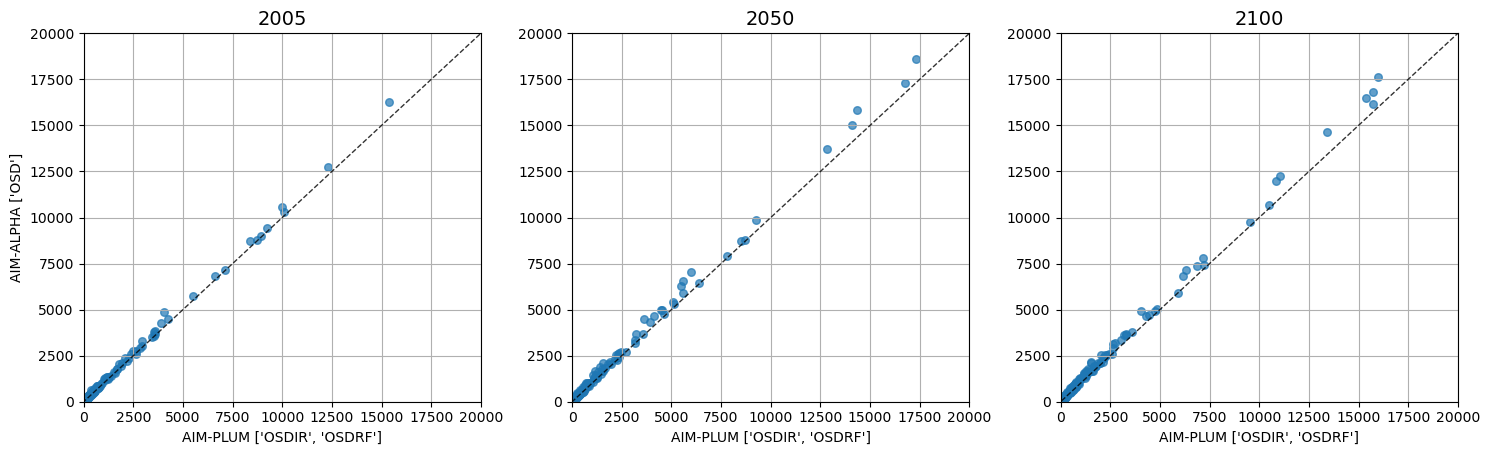

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=False, sharey=False)

for i, year in enumerate(years):

    # --- 主 type 的 sum ---
    df1_main = (
        df1[
            (df1["scenario"] == scenario_sel) &
            (df1["type"].isin(type1_list)) &
            (df1["year"] == year)
        ]
        .groupby("basin", as_index=False)["value"]
        .sum()
        .rename(columns={"value": "value_main"})
    )

    # --- 只有 CL 时才做减法 ---
    if type1_list == ["CL"]:

        minus_type = type1_minus[0]

        df1_minus = (
            df1[
                (df1["scenario"] == scenario_sel) &
                (df1["type"] == minus_type) &
                (df1["year"] == year)
            ]
            .groupby("basin", as_index=False)["value"]
            .sum()
            .rename(columns={"value": "value_minus"})
        )

        # basin 对齐
        df1_y = pd.merge(
            df1_main,
            df1_minus,
            on="basin",
            how="left"
        )

        # 不存在的当 0
        df1_y["value_minus"] = df1_y["value_minus"].fillna(0)

        # 真正用于画图的值
        df1_y["value"] = df1_y["value_main"] - df1_y["value_minus"]

        df1_y = df1_y[["basin", "value"]]

    else:
        # 原逻辑
        df1_y = df1_main.rename(columns={"value_main": "value"})


    df2_y = (
        df2[
            (df2["type"].isin(type2_list)) &
            (df2["year"] == year)
        ]
        .groupby("basin", as_index=False)["area"]
        .sum()
    )

    # basin 对齐
    df_merge = pd.merge(df2_y, df1_y, on="basin", how="inner")

    ax = axes[i]

    if df_merge.empty:
        ax.set_title(f"{year} (no data)")
        ax.axis("off")
        continue

    ax.scatter(
        df_merge["area"],
        df_merge["value"],
        alpha=0.7,
        s=30
    )

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    vmin = max(xmin, ymin)
    vmax = min(xmax, ymax)
    ax.plot(
        [vmin, vmax],
        [vmin, vmax],
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        color="black"
    )
    lim = min(20000, max(xmax, ymax))
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

    ax.set_title(f"{year}",fontsize=14)
    ax.grid(True)

    if i == 0:
        ax.set_ylabel(f"AIM-ALPHA {type1_list}")
    ax.set_xlabel(f"AIM-PLUM {type2_list}")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()